# WCCI Do-Nothing And Greedy Monthly Analysis

This notebook analyzes the downloaded WCCI `bus36_wcci` evaluation outputs by month.

It compares:

- full do-nothing evaluations on train/test/all splits,
- one or more simulator-greedy evaluations using reduced action spaces,
- matched do-nothing replay inside each greedy CSV when available.

The greedy section is intentionally multi-run: add or download folders for 64, 128, 256, 512, 1024/1208 actions and rerun the notebook to compare them side by side.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")


def find_task_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == "Topology_Task" and (candidate / "outputs").exists():
            return candidate
        nested = candidate / "Topology_Task"
        if (nested / "outputs").exists():
            return nested
    raise FileNotFoundError("Could not find Topology_Task/outputs from the current working directory.")


TASK_DIR = find_task_dir()
OUTPUTS_DIR = TASK_DIR / "outputs"
GREEDY_EVAL_DIR = OUTPUTS_DIR / "teacher_student_greedy_eval"

DO_NOTHING_RUNS = {
    "train": OUTPUTS_DIR / "do_nothing_eval" / "wcci_train_detmaint",
    "test": OUTPUTS_DIR / "do_nothing_eval" / "wcci_test_detmaint",
    "all": OUTPUTS_DIR / "do_nothing_eval" / "wcci_all_detmaint",
}

# Editable greedy run list. Missing folders are skipped and shown in the source table.
# Keep labels short: they are used directly in legends.
GREEDY_RUNS = {
    "k64": GREEDY_EVAL_DIR / "test_fast_mk64",
    "k128": GREEDY_EVAL_DIR / "test_fast_mk128",
    "k256": GREEDY_EVAL_DIR / "test_fast_mk256",
    "k512": GREEDY_EVAL_DIR / "test_fast_mk512",
    "k1024": GREEDY_EVAL_DIR / "test_fast_mk1024",
}

# Also discover matching folders automatically, useful when the output folder names differ slightly.
AUTO_DISCOVER_GREEDY_RUNS = True
GREEDY_DISCOVERY_PATTERNS = [
    "test_fast_mk*",
    "wcci_h1*_test*_yesdn*",
    "wcci_h1*_test*_withdn*",
    "wcci_h1*_test*_nodn*",
]

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
MONTH_NAME_TO_NUM = {name.lower(): i + 1 for i, name in enumerate([
    "january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december"
])}

print(f"Task dir: {TASK_DIR}")
print(f"Outputs dir: {OUTPUTS_DIR}")
print(f"Greedy eval dir: {GREEDY_EVAL_DIR}")


Task dir: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task
Outputs dir: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs
Greedy eval dir: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/teacher_student_greedy_eval


In [2]:
def require_file(path: Path) -> Path:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def read_json(path: Path):
    with require_file(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def as_bool(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().map({"true": True, "false": False}).fillna(False)


def month_from_name(name):
    text = str(name).lower()
    match = re.search(r"scenario_([a-z]+)_", text)
    if not match:
        return np.nan
    return MONTH_NAME_TO_NUM.get(match.group(1), np.nan)


def add_month_columns(df, datetime_col, name_col):
    out = df.copy()
    dt = pd.to_datetime(out[datetime_col], errors="coerce") if datetime_col in out else pd.Series(pd.NaT, index=out.index)
    month_num = dt.dt.month.astype("float")
    if name_col in out:
        fallback = out[name_col].map(month_from_name)
        month_num = month_num.fillna(fallback)
    out["month_num"] = month_num.astype("Int64")
    out["month"] = out["month_num"].map(lambda x: MONTH_NAMES[int(x) - 1] if pd.notna(x) else "unknown")
    return out


def pct(series):
    return 100.0 * pd.to_numeric(series, errors="coerce")


def rel(path: Path) -> str:
    path = Path(path).resolve()
    try:
        return str(path.relative_to(TASK_DIR.resolve()))
    except ValueError:
        return str(path)


def print_plot_sources(title, paths):
    print(f"Plot source files for {title}:")
    for path in paths:
        print(f"  - {rel(Path(path))}")


def extract_action_set_size(value):
    text = str(value)
    patterns = [
        r"(?:^|[_-])mk(?P<k>\d+)(?:[_-]|$)",
        r"(?:^|[_-])k(?P<k>\d+)(?:[_-]|$)",
        r"(?:^|[_-])(?P<k>\d+)(?:[_-]test|[_-]actions|actions|a)(?:[_-]|$)",
    ]
    for pattern in patterns:
        match = re.search(pattern, text.lower())
        if match:
            return int(match.group("k"))
    return np.nan


def action_set_label(folder, explicit_label=None, action_set_size=None):
    if explicit_label:
        return str(explicit_label)
    if pd.notna(action_set_size):
        return f"k{int(action_set_size)}"
    return Path(folder).name


def greedy_csv_has_paired_do_nothing(csv_path):
    try:
        df = pd.read_csv(csv_path, usecols=lambda col: col == "do_nothing_survival")
    except Exception:
        return False
    if "do_nothing_survival" not in df:
        return False
    return pd.to_numeric(df["do_nothing_survival"], errors="coerce").notna().any()


def resolve_greedy_run_specs():
    raw_specs = []
    skipped = []
    seen = set()

    def add_spec(folder, label=None, configured=False):
        folder = Path(folder)
        key = str(folder.resolve()) if folder.exists() else str(folder)
        if key in seen:
            return
        seen.add(key)
        csv_path = folder / "greedy_vs_do_nothing_episodes.csv"
        json_path = folder / "greedy_vs_do_nothing_summary.json"
        action_set_size = extract_action_set_size(folder.name)
        label = action_set_label(folder, label, action_set_size)
        if csv_path.exists() and json_path.exists():
            raw_specs.append({
                "label": label,
                "folder": folder,
                "action_set_size": action_set_size,
                "csv": csv_path,
                "json": json_path,
                "has_paired_do_nothing": greedy_csv_has_paired_do_nothing(csv_path),
                "configured": bool(configured),
            })
        else:
            skipped.append({
                "label": label,
                "folder": folder,
                "reason": "missing greedy CSV or JSON",
            })

    for label, folder in GREEDY_RUNS.items():
        add_spec(folder, label=label, configured=True)

    if AUTO_DISCOVER_GREEDY_RUNS:
        for root in [OUTPUTS_DIR, GREEDY_EVAL_DIR]:
            if not root.exists():
                continue
            for pattern in GREEDY_DISCOVERY_PATTERNS:
                for folder in sorted(root.glob(pattern)):
                    if folder.is_dir():
                        add_spec(folder, configured=False)

    def spec_quality(spec):
        folder_text = str(spec["folder"])
        return (
            int(bool(spec.get("configured"))),
            int(bool(spec.get("has_paired_do_nothing"))),
            int("teacher_student_greedy_eval" in folder_text),
            int("yesdn" in folder_text or "withdn" in folder_text),
            -len(folder_text),
        )

    best_by_label = {}
    for spec in raw_specs:
        key = (spec["label"], None if pd.isna(spec["action_set_size"]) else int(spec["action_set_size"]))
        previous = best_by_label.get(key)
        if previous is None or spec_quality(spec) > spec_quality(previous):
            if previous is not None:
                skipped.append({
                    "label": previous["label"],
                    "folder": previous["folder"],
                    "reason": f"duplicate label; preferred {spec['folder']}",
                })
            best_by_label[key] = spec
        else:
            skipped.append({
                "label": spec["label"],
                "folder": spec["folder"],
                "reason": f"duplicate label; preferred {previous['folder']}",
            })

    specs = list(best_by_label.values())
    specs.sort(key=lambda item: (
        np.inf if pd.isna(item["action_set_size"]) else int(item["action_set_size"]),
        str(item["label"]),
        str(item["folder"]),
    ))
    return specs, skipped


def load_do_nothing_run(split, folder):
    folder = Path(folder)
    csv_path = require_file(folder / "do_nothing_episodes.csv")
    json_path = require_file(folder / "do_nothing_summary.json")
    df = pd.read_csv(csv_path)
    df["dataset_split"] = split
    df["policy"] = "do_nothing"
    df["source_folder"] = str(folder)
    df["source_csv"] = str(csv_path)
    df["survival"] = pd.to_numeric(df["survival"], errors="coerce")
    df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
    df["max_steps"] = pd.to_numeric(df["max_steps"], errors="coerce")
    df["full_survival"] = as_bool(df["full_survival"])
    df = add_month_columns(df, "chronic_datetime", "chronic_name")
    return df, read_json(json_path), {"csv": csv_path, "json": json_path}


def load_greedy_run(folder, *, label=None, action_set_size=np.nan):
    folder = Path(folder)
    csv_path = require_file(folder / "greedy_vs_do_nothing_episodes.csv")
    json_path = require_file(folder / "greedy_vs_do_nothing_summary.json")
    df = pd.read_csv(csv_path)
    summary = read_json(json_path)
    if pd.isna(action_set_size):
        action_set_size = extract_action_set_size(folder.name)
    label = action_set_label(folder, label, action_set_size)
    df["policy"] = "greedy"
    df["run_label"] = label
    df["action_set_size"] = action_set_size
    df["source_folder"] = str(folder)
    df["source_csv"] = str(csv_path)
    for col in ["greedy_survival", "do_nothing_survival", "survival_delta"]:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in ["greedy_steps", "do_nothing_steps", "max_steps", "greedy_nonidle_actions", "greedy_decision_states", "greedy_simulated_actions"]:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["greedy_full_survival"] = as_bool(df["greedy_full_survival"])
    if "do_nothing_full_survival" in df:
        df["do_nothing_full_survival"] = as_bool(df["do_nothing_full_survival"])
    df = add_month_columns(df, "greedy_chronic_datetime", "greedy_chronic_name")
    return df, summary, {"csv": csv_path, "json": json_path, "folder": folder}


def month_agg(df, survival_col, full_col=None, extra=None):
    agg = {
        "n": (survival_col, "size"),
        "mean_survival_pct": (survival_col, lambda s: 100.0 * pd.to_numeric(s, errors="coerce").mean()),
        "median_survival_pct": (survival_col, lambda s: 100.0 * pd.to_numeric(s, errors="coerce").median()),
    }
    if full_col is not None:
        agg["full_survival_rate_pct"] = (full_col, lambda s: 100.0 * as_bool(s).mean())
    if extra:
        agg.update(extra)
    result = df.groupby(["month_num", "month"], dropna=False).agg(**agg).reset_index()
    return result.sort_values("month_num")


def sort_by_run(df, month=True):
    cols = ["run_order"]
    if month and "month_num" in df:
        cols.append("month_num")
    return (
        df.assign(run_order=df["run_label"].map(RUN_LABEL_ORDER))
        .sort_values(cols)
        .drop(columns="run_order")
    )


In [3]:
do_nothing_frames = []
do_nothing_summaries = {}
source_files = {"do_nothing": {}, "greedy": {}}

for split, folder in DO_NOTHING_RUNS.items():
    df, summary, files = load_do_nothing_run(split, folder)
    do_nothing_frames.append(df)
    do_nothing_summaries[split] = summary
    source_files["do_nothing"][split] = files

do_nothing = pd.concat(do_nothing_frames, ignore_index=True)

greedy_specs, skipped_greedy_specs = resolve_greedy_run_specs()
if not greedy_specs:
    display(pd.DataFrame(skipped_greedy_specs))
    raise FileNotFoundError("No greedy evaluation folders were found. Update GREEDY_RUNS or GREEDY_DISCOVERY_PATTERNS in the configuration cell.")

greedy_frames = []
greedy_summaries = {}
for spec in greedy_specs:
    df, summary, files = load_greedy_run(
        spec["folder"],
        label=spec["label"],
        action_set_size=spec["action_set_size"],
    )
    label = spec["label"]
    greedy_frames.append(df)
    greedy_summaries[label] = summary
    source_files["greedy"][label] = files

greedy_all = pd.concat(greedy_frames, ignore_index=True)
greedy = greedy_all  # backward-compatible alias for ad-hoc cells
LOADED_GREEDY_LABELS = [spec["label"] for spec in greedy_specs]
RUN_LABEL_ORDER = {label: idx for idx, label in enumerate(LOADED_GREEDY_LABELS)}
RUN_COLORS = {
    label: plt.cm.viridis(x)
    for label, x in zip(LOADED_GREEDY_LABELS, np.linspace(0.15, 0.85, len(LOADED_GREEDY_LABELS)))
}

source_table = []
for split, files in source_files["do_nothing"].items():
    source_table.append({"kind": "do_nothing", "label": split, "action_set_size": np.nan, "split": split, "csv": rel(files["csv"]), "json": rel(files["json"])})
for spec in greedy_specs:
    files = source_files["greedy"][spec["label"]]
    summary = greedy_summaries[spec["label"]]
    source_table.append({"kind": "greedy", "label": spec["label"], "action_set_size": spec["action_set_size"], "split": summary.get("split", "unknown"), "csv": rel(files["csv"]), "json": rel(files["json"])})

source_table = pd.DataFrame(source_table)
display(source_table)
if skipped_greedy_specs:
    print("Configured/discovered greedy folders skipped because they are not available yet:")
    display(pd.DataFrame(skipped_greedy_specs).assign(folder=lambda d: d["folder"].map(rel)))
print(f"Loaded do-nothing episodes: {len(do_nothing):,}")
print(f"Loaded greedy runs: {len(greedy_specs):,}")
print(f"Loaded greedy episodes total: {len(greedy_all):,}")


,kind,label,action_set_size,split,csv,json
0,do_nothing,train,NaN,train,outputs/do_nothing_eval/wcci_train_detmaint/do...,outputs/do_nothing_eval/wcci_train_detmaint/do...
1,do_nothing,test,NaN,test,outputs/do_nothing_eval/wcci_test_detmaint/do_...,outputs/do_nothing_eval/wcci_test_detmaint/do_...
2,do_nothing,all,NaN,all,outputs/do_nothing_eval/wcci_all_detmaint/do_n...,outputs/do_nothing_eval/wcci_all_detmaint/do_n...
3,greedy,k64,64.0,test,outputs/teacher_student_greedy_eval/test_fast_...,outputs/teacher_student_greedy_eval/test_fast_...
4,greedy,k128,128.0,test,outputs/teacher_student_greedy_eval/test_fast_...,outputs/teacher_student_greedy_eval/test_fast_...
5,greedy,k256,256.0,test,outputs/teacher_student_greedy_eval/test_fast_...,outputs/teacher_student_greedy_eval/test_fast_...
6,greedy,k512,512.0,test,outputs/teacher_student_greedy_eval/test_fast_...,outputs/teacher_student_greedy_eval/test_fast_...
7,greedy,k1024,1024.0,test,outputs/teacher_student_greedy_eval/test_fast_...,outputs/teacher_student_greedy_eval/test_fast_...


Configured/discovered greedy folders skipped because they are not available yet:


,label,folder,reason
0,k256,outputs/wcci_h1_mk256_test_50chronics_nodn,duplicate label; preferred /Users/corentinplum...
1,k1024,outputs/teacher_student_greedy_eval/wcci_h1_mk...,duplicate label; preferred /Users/corentinplum...
2,k256,outputs/teacher_student_greedy_eval/wcci_h1_mk...,duplicate label; preferred /Users/corentinplum...
3,k512,outputs/teacher_student_greedy_eval/wcci_h1_mk...,duplicate label; preferred /Users/corentinplum...


Loaded do-nothing episodes: 5,760
Loaded greedy runs: 5
Loaded greedy episodes total: 250


## 1. Global Sanity Check

In [4]:
global_summary = []
for split, summary in do_nothing_summaries.items():
    global_summary.append({
        "policy": "do_nothing",
        "label": split,
        "action_set_size": np.nan,
        "split": split,
        "episodes": summary.get("n_episodes"),
        "unique_fingerprints": summary.get("n_unique_fingerprints"),
        "mean_survival_pct": 100.0 * summary.get("mean_survival", np.nan),
        "median_survival_pct": 100.0 * summary.get("median_survival", np.nan),
        "full_survival_rate_pct": 100.0 * summary.get("full_survival_rate", np.nan),
        "source": rel(source_files["do_nothing"][split]["json"]),
    })

for label in LOADED_GREEDY_LABELS:
    summary = greedy_summaries[label]
    sub = greedy_all[greedy_all["run_label"] == label]
    global_summary.append({
        "policy": "greedy",
        "label": label,
        "action_set_size": sub["action_set_size"].iloc[0],
        "split": summary.get("split", "unknown"),
        "episodes": summary.get("n_episodes", len(sub)),
        "unique_fingerprints": sub["greedy_chronic_fingerprint"].nunique(),
        "mean_survival_pct": 100.0 * summary.get("greedy_mean_survival", sub["greedy_survival"].mean()),
        "median_survival_pct": 100.0 * sub["greedy_survival"].median(),
        "full_survival_rate_pct": 100.0 * summary.get("greedy_full_survival_rate", sub["greedy_full_survival"].mean()),
        "source": rel(source_files["greedy"][label]["json"]),
    })

global_summary = pd.DataFrame(global_summary)
display(global_summary.round(3))

train_mean = do_nothing_summaries["train"]["mean_survival"]
test_mean = do_nothing_summaries["test"]["mean_survival"]
train_n = do_nothing_summaries["train"]["n_episodes"]
test_n = do_nothing_summaries["test"]["n_episodes"]
weighted_train_test = (train_n * train_mean + test_n * test_mean) / (train_n + test_n)
print(f"Weighted train/test do-nothing mean: {100 * weighted_train_test:.3f}%")
print(f"Downloaded all do-nothing mean:       {100 * do_nothing_summaries['all']['mean_survival']:.3f}%")


,policy,label,action_set_size,split,episodes,unique_fingerprints,mean_survival_pct,median_survival_pct,full_survival_rate_pct,source
0,do_nothing,train,NaN,train,2304,2304,26.422,12.131,6.597,outputs/do_nothing_eval/wcci_train_detmaint/do...
1,do_nothing,test,NaN,test,576,576,27.257,12.143,6.771,outputs/do_nothing_eval/wcci_test_detmaint/do_...
2,do_nothing,all,NaN,all,2880,2880,27.001,12.131,7.465,outputs/do_nothing_eval/wcci_all_detmaint/do_n...
3,greedy,k64,64.0,test,50,50,55.244,52.828,22.000,outputs/teacher_student_greedy_eval/test_fast_...
4,greedy,k128,128.0,test,50,50,60.652,66.541,22.000,outputs/teacher_student_greedy_eval/test_fast_...
5,greedy,k256,256.0,test,50,50,68.610,78.765,36.000,outputs/teacher_student_greedy_eval/test_fast_...
6,greedy,k512,512.0,test,50,50,71.205,79.037,40.000,outputs/teacher_student_greedy_eval/test_fast_...
7,greedy,k1024,1024.0,test,50,50,78.177,100.000,54.000,outputs/teacher_student_greedy_eval/test_fast_...


Weighted train/test do-nothing mean: 26.589%
Downloaded all do-nothing mean:       27.001%


## 1b. Total Greedy Survival By Reduced Action Space

This table aggregates each greedy evaluation over all evaluated chronics. It is the quickest view for comparing 64/128/256/512/1024 reduced action spaces before looking at the monthly breakdown.


In [5]:
greedy_total_survival = (
    greedy_all.groupby(["run_label", "action_set_size"], dropna=False)
    .agg(
        episodes=("greedy_survival", "size"),
        unique_fingerprints=("greedy_chronic_fingerprint", "nunique"),
        mean_episodic_survival_pct=("greedy_survival", lambda s: 100.0 * pd.to_numeric(s, errors="coerce").mean()),
        median_episodic_survival_pct=("greedy_survival", lambda s: 100.0 * pd.to_numeric(s, errors="coerce").median()),
        std_episodic_survival_pct=("greedy_survival", lambda s: 100.0 * pd.to_numeric(s, errors="coerce").std(ddof=0)),
        full_survival_rate_pct=("greedy_full_survival", lambda s: 100.0 * as_bool(s).mean()),
        mean_nonidle_actions=("greedy_nonidle_actions", "mean"),
        mean_decision_states=("greedy_decision_states", "mean"),
        mean_simulated_actions=("greedy_simulated_actions", "mean"),
    )
    .reset_index()
)

if "do_nothing_survival" in greedy_all.columns:
    paired = greedy_all.dropna(subset=["do_nothing_survival"]).copy()
    if len(paired):
        paired_summary = (
            paired.groupby(["run_label", "action_set_size"], dropna=False)
            .agg(
                paired_do_nothing_episodes=("do_nothing_survival", "size"),
                paired_do_nothing_mean_survival_pct=("do_nothing_survival", lambda s: 100.0 * pd.to_numeric(s, errors="coerce").mean()),
                mean_delta_vs_paired_do_nothing_pct=("survival_delta", lambda s: 100.0 * pd.to_numeric(s, errors="coerce").mean()),
            )
            .reset_index()
        )
        greedy_total_survival = greedy_total_survival.merge(
            paired_summary,
            on=["run_label", "action_set_size"],
            how="left",
        )

greedy_total_survival = sort_by_run(greedy_total_survival, month=False)
display(greedy_total_survival.round(3))


,run_label,action_set_size,episodes,unique_fingerprints,mean_episodic_survival_pct,median_episodic_survival_pct,std_episodic_survival_pct,full_survival_rate_pct,mean_nonidle_actions,mean_decision_states,mean_simulated_actions,paired_do_nothing_episodes,paired_do_nothing_mean_survival_pct,mean_delta_vs_paired_do_nothing_pct
4,k64,64,50,50,55.244,52.828,34.922,22.0,73.94,86.18,21803.54,50,28.304,26.939
1,k128,128,50,50,60.652,66.541,33.615,22.0,97.00,106.70,48761.90,50,28.304,32.348
2,k256,256,50,50,68.610,78.765,32.890,36.0,120.08,130.22,92846.86,50,28.304,40.306
3,k512,512,50,50,71.205,79.037,32.095,40.0,96.34,102.54,125611.50,50,28.304,42.901
0,k1024,1024,50,50,78.177,100.000,31.033,54.0,98.36,104.18,234300.82,50,28.304,49.873


## 2. Do-Nothing Results By Month

In [6]:
do_nothing_month = (
    do_nothing.groupby(["dataset_split", "month_num", "month"], dropna=False)
    .agg(
        n=("survival", "size"),
        mean_survival_pct=("survival", lambda s: 100.0 * s.mean()),
        median_survival_pct=("survival", lambda s: 100.0 * s.median()),
        full_survival_rate_pct=("full_survival", lambda s: 100.0 * s.mean()),
        mean_steps=("steps", "mean"),
        mean_peak_rho=("peak_max_rho", "mean"),
    )
    .reset_index()
    .sort_values(["dataset_split", "month_num"])
)

display(do_nothing_month.round(3))

,dataset_split,month_num,month,n,mean_survival_pct,median_survival_pct,full_survival_rate_pct,mean_steps,mean_peak_rho
0,all,1,Jan,240,9.090,8.670,0.000,732.808,1.920
1,all,2,Feb,240,2.561,1.278,0.000,206.467,1.335
2,all,3,Mar,240,22.635,16.497,0.833,1824.833,1.389
3,all,4,Apr,240,53.040,54.999,18.333,4276.067,1.486
4,all,5,May,240,61.958,58.608,31.667,4995.092,1.308
5,all,6,Jun,240,48.827,44.245,17.917,3936.417,1.441
6,all,7,Jul,240,37.621,33.546,5.417,3033.042,1.550
7,all,8,Aug,240,24.709,20.578,2.500,1992.021,1.635
8,all,9,Sep,240,42.925,35.990,12.917,3460.625,1.556
9,all,10,Oct,240,5.176,5.296,0.000,417.254,2.180


Plot source files for do-nothing monthly mean survival:
  - outputs/do_nothing_eval/wcci_train_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_all_detmaint/do_nothing_episodes.csv


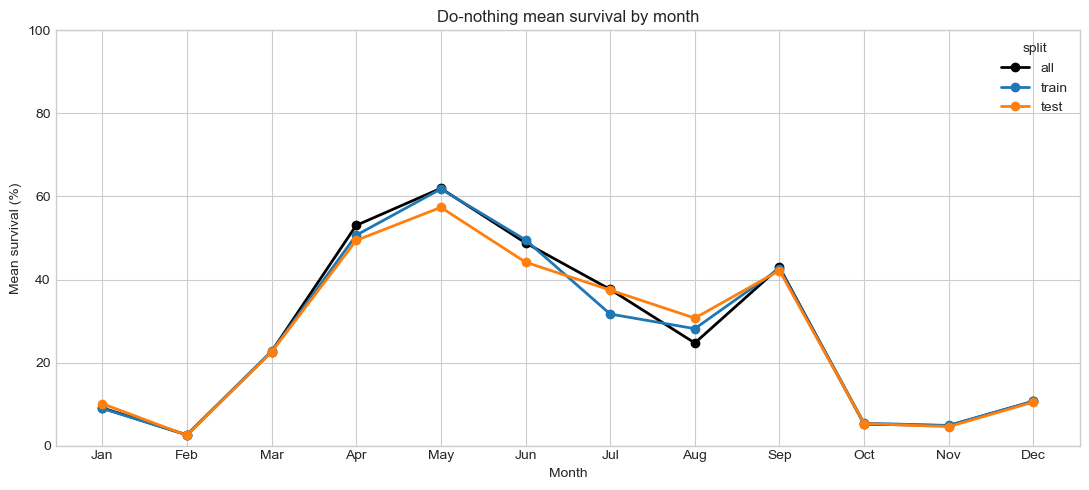

In [7]:
plot_paths = [files["csv"] for files in source_files["do_nothing"].values()]
print_plot_sources("do-nothing monthly mean survival", plot_paths)

fig, ax = plt.subplots(figsize=(11, 5))
for split, color in [("all", "black"), ("train", "tab:blue"), ("test", "tab:orange")]:
    sub = do_nothing_month[do_nothing_month["dataset_split"] == split]
    ax.plot(sub["month_num"], sub["mean_survival_pct"], marker="o", linewidth=2, label=split, color=color)
ax.set_xticks(range(1, 13), MONTH_NAMES)
ax.set_ylabel("Mean survival (%)")
ax.set_xlabel("Month")
ax.set_title("Do-nothing mean survival by month")
ax.legend(title="split")
ax.set_ylim(0, max(100, do_nothing_month["mean_survival_pct"].max() * 1.08))
fig.tight_layout()
plt.show()

Plot source files for do-nothing monthly counts and full-survival rates:
  - outputs/do_nothing_eval/wcci_train_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv
  - outputs/do_nothing_eval/wcci_all_detmaint/do_nothing_episodes.csv


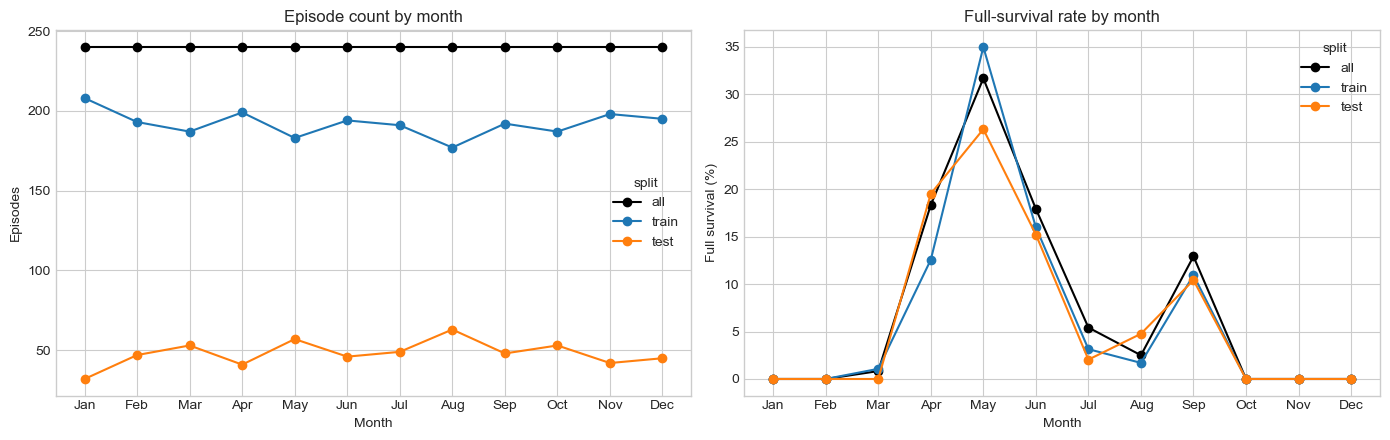

In [8]:
print_plot_sources("do-nothing monthly counts and full-survival rates", plot_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
for split, color in [("all", "black"), ("train", "tab:blue"), ("test", "tab:orange")]:
    sub = do_nothing_month[do_nothing_month["dataset_split"] == split]
    axes[0].plot(sub["month_num"], sub["n"], marker="o", label=split, color=color)
    axes[1].plot(sub["month_num"], sub["full_survival_rate_pct"], marker="o", label=split, color=color)
axes[0].set_title("Episode count by month")
axes[0].set_ylabel("Episodes")
axes[1].set_title("Full-survival rate by month")
axes[1].set_ylabel("Full survival (%)")
for ax in axes:
    ax.set_xticks(range(1, 13), MONTH_NAMES)
    ax.set_xlabel("Month")
    ax.legend(title="split")
fig.tight_layout()
plt.show()

## 3. Greedy Samples By Month

Each curve corresponds to one reduced action set. The notebook loads every available folder configured/discovered above, so adding 64/128/256/512/1024/1208 evaluations only requires rerunning from the configuration cell.


In [9]:
greedy_month = (
    greedy_all.groupby(["run_label", "action_set_size", "month_num", "month"], dropna=False)
    .agg(
        n=("greedy_survival", "size"),
        mean_greedy_survival_pct=("greedy_survival", lambda s: 100.0 * s.mean()),
        median_greedy_survival_pct=("greedy_survival", lambda s: 100.0 * s.median()),
        greedy_full_survival_rate_pct=("greedy_full_survival", lambda s: 100.0 * s.mean()),
        mean_nonidle_actions=("greedy_nonidle_actions", "mean"),
        mean_decision_states=("greedy_decision_states", "mean"),
        mean_simulated_actions=("greedy_simulated_actions", "mean"),
    )
    .reset_index()
)

greedy_month = sort_by_run(greedy_month)
display(greedy_month.round(3))


,run_label,action_set_size,month_num,month,n,mean_greedy_survival_pct,median_greedy_survival_pct,greedy_full_survival_rate_pct,mean_nonidle_actions,mean_decision_states,mean_simulated_actions
48,k64,64,1,Jan,3,54.982,79.831,0.000,118.000,157.667,39889.667
49,k64,64,2,Feb,3,68.879,100.000,66.667,194.000,234.667,59370.667
50,k64,64,3,Mar,6,88.485,100.000,83.333,55.667,65.333,16529.333
51,k64,64,4,Apr,1,28.579,28.579,0.000,20.000,20.000,5060.000
52,k64,64,5,May,4,22.739,24.491,0.000,36.750,53.000,13409.000
53,k64,64,6,Jun,5,68.951,72.823,20.000,28.600,30.200,7640.600
54,k64,64,7,Jul,4,70.147,87.119,0.000,39.750,50.250,12713.250
55,k64,64,8,Aug,5,33.724,31.444,0.000,15.600,16.600,4199.800
56,k64,64,9,Sep,3,40.685,44.245,0.000,9.667,11.667,2951.667
57,k64,64,10,Oct,6,40.234,34.718,16.667,65.500,79.333,20071.333


Plot source files for greedy action-set monthly survival:
  - outputs/teacher_student_greedy_eval/test_fast_mk64/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk128/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk256/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk512/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk1024/greedy_vs_do_nothing_episodes.csv


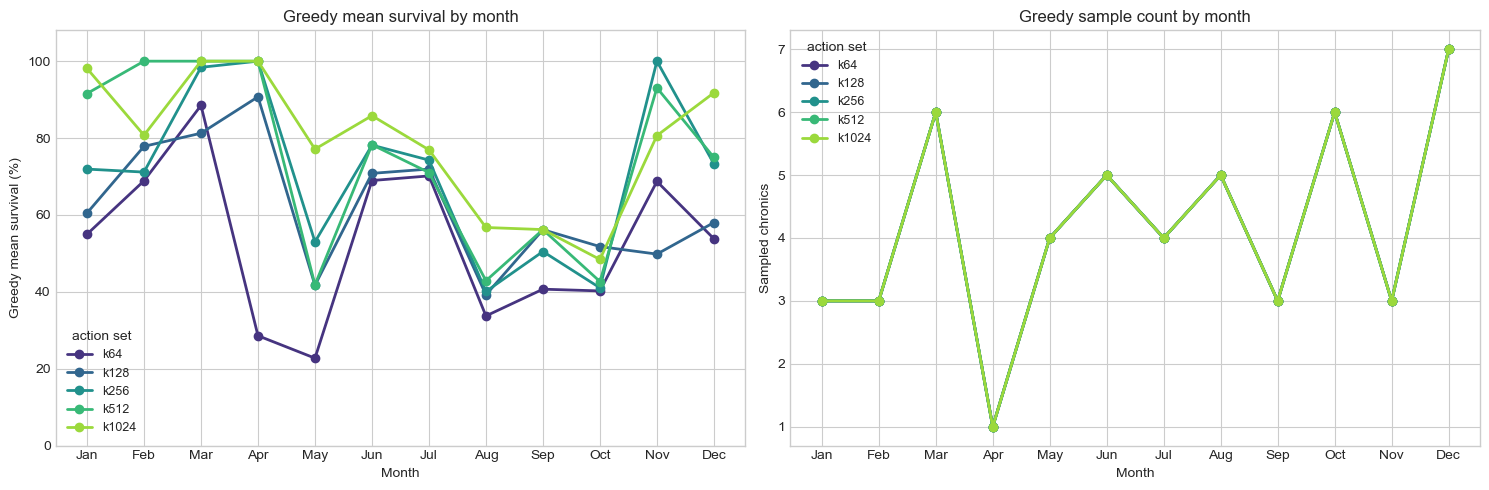

In [10]:
print_plot_sources("greedy action-set monthly survival", [files["csv"] for files in source_files["greedy"].values()])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for label in LOADED_GREEDY_LABELS:
    sub = greedy_month[greedy_month["run_label"] == label]
    color = RUN_COLORS[label]
    axes[0].plot(sub["month_num"], sub["mean_greedy_survival_pct"], marker="o", linewidth=2, label=label, color=color)
    axes[1].plot(sub["month_num"], sub["n"], marker="o", linewidth=2, label=label, color=color)

axes[0].set_ylabel("Greedy mean survival (%)")
axes[0].set_title("Greedy mean survival by month")
axes[0].set_ylim(0, max(100, greedy_month["mean_greedy_survival_pct"].max() * 1.08))
axes[1].set_ylabel("Sampled chronics")
axes[1].set_title("Greedy sample count by month")

for ax in axes:
    ax.set_xticks(range(1, 13), MONTH_NAMES)
    ax.set_xlabel("Month")
    ax.legend(title="action set", fontsize=9)
fig.tight_layout()
plt.show()


## 4. Greedy Vs Do-Nothing On The Same Sample

For each greedy run, this section prefers the paired do-nothing replay saved inside `greedy_vs_do_nothing_episodes.csv` (`COMPARE_DO_NOTHING=true`).

If a run does not contain paired do-nothing values, the notebook falls back to matching against the downloaded full-test do-nothing CSV by chronic fingerprint.


In [11]:
comparison_frames = []
comparison_sources = set()
comparison_source_rows = []

test_baseline = (
    do_nothing[do_nothing["dataset_split"] == "test"]
    .rename(columns={
        "survival": "baseline_survival",
        "full_survival": "baseline_full_survival",
        "steps": "baseline_steps",
        "chronic_name": "baseline_chronic_name",
        "chronic_fingerprint": "baseline_chronic_fingerprint",
        "chronic_seed": "baseline_chronic_seed",
    })
)

for label in LOADED_GREEDY_LABELS:
    g = greedy_all[greedy_all["run_label"] == label].copy()
    paired_available = "do_nothing_survival" in g and g["do_nothing_survival"].notna().any()
    greedy_csv = source_files["greedy"][label]["csv"]
    comparison_sources.add(greedy_csv)

    if paired_available:
        comp = g.copy()
        comp["baseline_source"] = "paired do-nothing replay inside greedy CSV"
        comp["baseline_survival"] = comp["do_nothing_survival"]
        comp["baseline_full_survival"] = comp["do_nothing_full_survival"]
        comp["baseline_steps"] = comp["do_nothing_steps"]
        comp["baseline_chronic_name"] = comp["do_nothing_chronic_name"]
        comp["baseline_chronic_fingerprint"] = comp["do_nothing_chronic_fingerprint"]
    else:
        comp = g.merge(
            test_baseline[["baseline_chronic_fingerprint", "baseline_chronic_name", "baseline_survival", "baseline_full_survival", "baseline_steps", "baseline_chronic_seed"]],
            left_on="greedy_chronic_fingerprint",
            right_on="baseline_chronic_fingerprint",
            how="left",
        )
        comp["baseline_source"] = "downloaded full-test do-nothing CSV matched by fingerprint"
        comparison_sources.add(source_files["do_nothing"]["test"]["csv"])

    comp["delta_vs_baseline"] = comp["greedy_survival"] - comp["baseline_survival"]
    comparison_frames.append(comp)
    comparison_source_rows.append({
        "run_label": label,
        "paired_replay_available": paired_available,
        "baseline_match_rate_pct": 100.0 * comp["baseline_survival"].notna().mean(),
        "baseline_source": comp["baseline_source"].iloc[0] if len(comp) else "none",
    })

comparison = pd.concat(comparison_frames, ignore_index=True)
comparison_sources = sorted(comparison_sources, key=lambda path: str(path))
comparison_source_table = pd.DataFrame(comparison_source_rows)
display(comparison_source_table.round(3))

sample_summary = (
    comparison.groupby(["run_label", "action_set_size"], dropna=False)
    .agg(
        n=("greedy_survival", "size"),
        unique_fingerprints=("greedy_chronic_fingerprint", "nunique"),
        greedy_mean_survival_pct=("greedy_survival", lambda s: 100.0 * s.mean()),
        baseline_mean_survival_pct=("baseline_survival", lambda s: 100.0 * s.mean()),
        mean_delta_pct=("delta_vs_baseline", lambda s: 100.0 * s.mean()),
        greedy_full_survival_rate_pct=("greedy_full_survival", lambda s: 100.0 * s.mean()),
        baseline_full_survival_rate_pct=("baseline_full_survival", lambda s: 100.0 * as_bool(s).mean()),
        mean_nonidle_actions=("greedy_nonidle_actions", "mean"),
        mean_decision_states=("greedy_decision_states", "mean"),
    )
    .reset_index()
)
sample_summary = sort_by_run(sample_summary, month=False)
display(sample_summary.round(3))

comparison_detail = comparison[[
    "run_label", "action_set_size", "episode", "requested_chronic_id", "month", "greedy_chronic_name", "baseline_chronic_name",
    "greedy_survival", "baseline_survival", "delta_vs_baseline", "greedy_full_survival", "baseline_full_survival",
    "greedy_nonidle_actions", "greedy_decision_states"
]].sort_values(["action_set_size", "episode"])
display(comparison_detail.round(4))


,run_label,paired_replay_available,baseline_match_rate_pct,baseline_source
0,k64,True,100.0,paired do-nothing replay inside greedy CSV
1,k128,True,100.0,paired do-nothing replay inside greedy CSV
2,k256,True,100.0,paired do-nothing replay inside greedy CSV
3,k512,True,100.0,paired do-nothing replay inside greedy CSV
4,k1024,True,100.0,paired do-nothing replay inside greedy CSV


,run_label,action_set_size,n,unique_fingerprints,greedy_mean_survival_pct,baseline_mean_survival_pct,mean_delta_pct,greedy_full_survival_rate_pct,baseline_full_survival_rate_pct,mean_nonidle_actions,mean_decision_states
4,k64,64,50,50,55.244,28.304,26.939,22.0,4.0,73.94,86.18
1,k128,128,50,50,60.652,28.304,32.348,22.0,4.0,97.00,106.70
2,k256,256,50,50,68.610,28.304,40.306,36.0,4.0,120.08,130.22
3,k512,512,50,50,71.205,28.304,42.901,40.0,4.0,96.34,102.54
0,k1024,1024,50,50,78.177,28.304,49.873,54.0,4.0,98.36,104.18


,run_label,action_set_size,episode,requested_chronic_id,month,greedy_chronic_name,baseline_chronic_name,greedy_survival,baseline_survival,delta_vs_baseline,greedy_full_survival,baseline_full_survival,greedy_nonidle_actions,greedy_decision_states
0,k64,64,0,40,Dec,Scenario_december_130,Scenario_december_130,0.4784,0.1202,0.3582,False,False,130,148
1,k64,64,1,16,May,Scenario_may_238,Scenario_may_238,0.2667,0.8719,-0.6052,False,False,23,26
2,k64,64,2,471,Mar,Scenario_march_076,Scenario_march_076,1.0000,0.1589,0.8411,True,False,50,51
3,k64,64,3,448,Jul,Scenario_july_022,Scenario_july_022,0.1209,0.0856,0.0354,False,False,29,63
4,k64,64,4,395,Aug,Scenario_august_227,Scenario_august_227,0.3144,0.3003,0.0141,False,False,19,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,k1024,1024,45,169,Jun,Scenario_june_181,Scenario_june_181,0.7625,0.7282,0.0342,False,False,46,108
246,k1024,1024,46,301,Dec,Scenario_december_065,Scenario_december_065,1.0000,0.1216,0.8784,True,False,400,402
247,k1024,1024,47,368,Dec,Scenario_december_017,Scenario_december_017,0.4240,0.1016,0.3224,False,False,76,77
248,k1024,1024,48,305,Dec,Scenario_december_096,Scenario_december_096,1.0000,0.0678,0.9322,True,False,369,371


In [12]:
comparison_month = (
    comparison.groupby(["run_label", "action_set_size", "month_num", "month"], dropna=False)
    .agg(
        n=("greedy_survival", "size"),
        greedy_mean_survival_pct=("greedy_survival", lambda s: 100.0 * s.mean()),
        baseline_mean_survival_pct=("baseline_survival", lambda s: 100.0 * s.mean()),
        mean_delta_pct=("delta_vs_baseline", lambda s: 100.0 * s.mean()),
        greedy_full_survival_rate_pct=("greedy_full_survival", lambda s: 100.0 * s.mean()),
        baseline_full_survival_rate_pct=("baseline_full_survival", lambda s: 100.0 * as_bool(s).mean()),
    )
    .reset_index()
)
comparison_month = sort_by_run(comparison_month)
display(comparison_month.round(3))


,run_label,action_set_size,month_num,month,n,greedy_mean_survival_pct,baseline_mean_survival_pct,mean_delta_pct,greedy_full_survival_rate_pct,baseline_full_survival_rate_pct
48,k64,64,1,Jan,3,54.982,13.442,41.541,0.000,0.0
49,k64,64,2,Feb,3,68.879,1.228,67.651,66.667,0.0
50,k64,64,3,Mar,6,88.485,14.978,73.507,83.333,0.0
51,k64,64,4,Apr,1,28.579,83.540,-54.962,0.000,0.0
52,k64,64,5,May,4,22.739,58.221,-35.481,0.000,25.0
53,k64,64,6,Jun,5,68.951,68.271,0.680,20.000,20.0
54,k64,64,7,Jul,4,70.147,45.135,25.012,0.000,0.0
55,k64,64,8,Aug,5,33.724,39.372,-5.649,0.000,0.0
56,k64,64,9,Sep,3,40.685,40.689,-0.004,0.000,0.0
57,k64,64,10,Oct,6,40.234,5.487,34.747,16.667,0.0


Plot source files for greedy action sets vs matched do-nothing monthly comparison:
  - outputs/teacher_student_greedy_eval/test_fast_mk1024/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk128/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk256/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk512/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk64/greedy_vs_do_nothing_episodes.csv


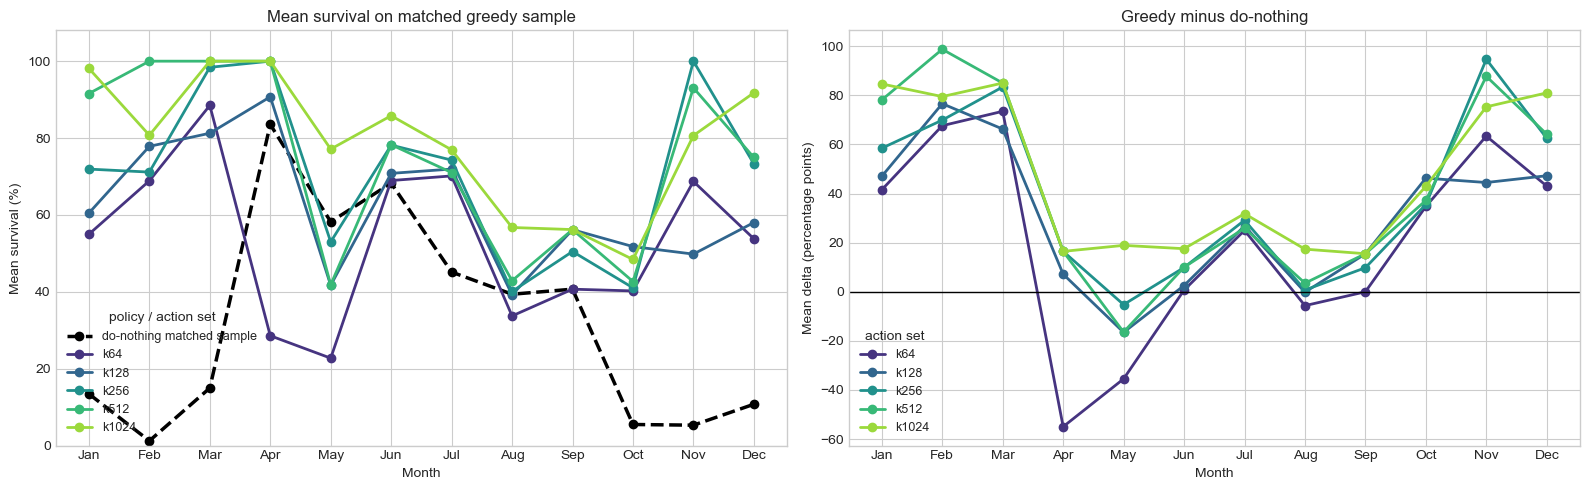

In [13]:
print_plot_sources("greedy action sets vs matched do-nothing monthly comparison", comparison_sources)

baseline_reference = (
    comparison.dropna(subset=["baseline_survival"])
    .drop_duplicates(["baseline_chronic_fingerprint"])
    .groupby(["month_num", "month"], dropna=False)
    .agg(
        n=("baseline_survival", "size"),
        baseline_mean_survival_pct=("baseline_survival", lambda s: 100.0 * s.mean()),
    )
    .reset_index()
    .sort_values("month_num")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
axes[0].plot(
    baseline_reference["month_num"],
    baseline_reference["baseline_mean_survival_pct"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="do-nothing matched sample",
    color="black",
)
for label in LOADED_GREEDY_LABELS:
    sub = comparison_month[comparison_month["run_label"] == label]
    color = RUN_COLORS[label]
    axes[0].plot(sub["month_num"], sub["greedy_mean_survival_pct"], marker="o", linewidth=2, label=label, color=color)
    axes[1].plot(sub["month_num"], sub["mean_delta_pct"], marker="o", linewidth=2, label=label, color=color)

axes[0].set_title("Mean survival on matched greedy sample")
axes[0].set_ylabel("Mean survival (%)")
axes[0].set_ylim(0, max(100, comparison_month["greedy_mean_survival_pct"].max() * 1.08, baseline_reference["baseline_mean_survival_pct"].max() * 1.08))
axes[0].legend(title="policy / action set", fontsize=9)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Greedy minus do-nothing")
axes[1].set_ylabel("Mean delta (percentage points)")
axes[1].legend(title="action set", fontsize=9)

for ax in axes:
    ax.set_xticks(range(1, 13), MONTH_NAMES)
    ax.set_xlabel("Month")
fig.tight_layout()
plt.show()


Plot source files for per-chronic greedy action sets vs do-nothing scatter:
  - outputs/teacher_student_greedy_eval/test_fast_mk1024/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk128/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk256/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk512/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk64/greedy_vs_do_nothing_episodes.csv


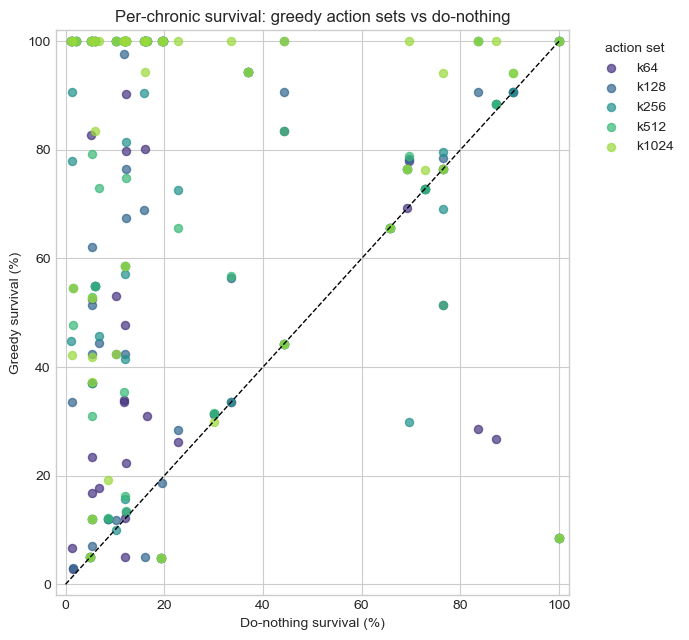

In [14]:
print_plot_sources("per-chronic greedy action sets vs do-nothing scatter", comparison_sources)

fig, ax = plt.subplots(figsize=(7, 6.5))
valid = comparison.dropna(subset=["baseline_survival", "greedy_survival"])
for label in LOADED_GREEDY_LABELS:
    sub = valid[valid["run_label"] == label]
    ax.scatter(100 * sub["baseline_survival"], 100 * sub["greedy_survival"], alpha=0.7, s=34, label=label, color=RUN_COLORS[label])
ax.plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=1)
ax.set_xlim(-2, 102)
ax.set_ylim(-2, 102)
ax.set_xlabel("Do-nothing survival (%)")
ax.set_ylabel("Greedy survival (%)")
ax.set_title("Per-chronic survival: greedy action sets vs do-nothing")
ax.legend(title="action set", bbox_to_anchor=(1.03, 1), loc="upper left")
fig.tight_layout()
plt.show()


## 5. Sample Coverage Audit

This verifies which months are present in each greedy evaluation sample. If all action-set evaluations use the same target fingerprint list, the monthly counts should match across action-set sizes.


In [15]:
test_month_counts = (
    do_nothing[do_nothing["dataset_split"] == "test"]
    .groupby(["month_num", "month"])
    .size()
    .rename("test_count")
    .reset_index()
)
sample_month_counts = (
    greedy_all.groupby(["run_label", "action_set_size", "month_num", "month"])
    .size()
    .rename("sample_count")
    .reset_index()
)
coverage = sample_month_counts.merge(test_month_counts, on=["month_num", "month"], how="left").fillna({"sample_count": 0})
coverage["sample_pct_of_test_month"] = 100.0 * coverage["sample_count"] / coverage["test_count"]
coverage = sort_by_run(coverage)
display(coverage.round(3))

sample_chronics = greedy_all[[
    "run_label", "action_set_size", "episode", "requested_chronic_id", "month", "greedy_chronic_name", "greedy_chronic_path",
    "greedy_chronic_index", "greedy_chronic_order_position", "greedy_chronic_fingerprint", "greedy_survival", "greedy_full_survival"
]].sort_values(["action_set_size", "episode"])
display(sample_chronics.round(4))


,run_label,action_set_size,month_num,month,sample_count,test_count,sample_pct_of_test_month
48,k64,64,1,Jan,3,32,9.375
49,k64,64,2,Feb,3,47,6.383
50,k64,64,3,Mar,6,53,11.321
51,k64,64,4,Apr,1,41,2.439
52,k64,64,5,May,4,57,7.018
53,k64,64,6,Jun,5,46,10.870
54,k64,64,7,Jul,4,49,8.163
55,k64,64,8,Aug,5,63,7.937
56,k64,64,9,Sep,3,48,6.250
57,k64,64,10,Oct,6,53,11.321


,run_label,action_set_size,episode,requested_chronic_id,month,greedy_chronic_name,greedy_chronic_path,greedy_chronic_index,greedy_chronic_order_position,greedy_chronic_fingerprint,greedy_survival,greedy_full_survival
0,k64,64,0,40,Dec,Scenario_december_130,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,610,41,73e168f338d0,0.4784,False
1,k64,64,1,16,May,Scenario_may_238,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,2158,17,a04f9cdbf89e,0.2667,False
2,k64,64,2,471,Mar,Scenario_march_076,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,1756,472,a82fbe0e1bab,1.0000,True
3,k64,64,3,448,Jul,Scenario_july_022,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,1222,449,eefe7d5613d0,0.1209,False
4,k64,64,4,395,Aug,Scenario_august_227,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,467,396,9c66241c54cd,0.3144,False
...,...,...,...,...,...,...,...,...,...,...,...,...
245,k1024,1024,45,169,Jun,Scenario_june_181,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,1621,170,0dbdb8476615,0.7625,False
246,k1024,1024,46,301,Dec,Scenario_december_065,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,545,302,4dfd6d3ec0dd,1.0000,True
247,k1024,1024,47,368,Dec,Scenario_december_017,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,497,369,50f9022e7c14,0.4240,False
248,k1024,1024,48,305,Dec,Scenario_december_096,/home/plumet/data_grid2op/l2rpn_wcci_2020/chro...,576,306,786598b254ec,1.0000,True


Plot source files for test distribution vs greedy sample distributions:
  - outputs/do_nothing_eval/wcci_test_detmaint/do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk64/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk128/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk256/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk512/greedy_vs_do_nothing_episodes.csv
  - outputs/teacher_student_greedy_eval/test_fast_mk1024/greedy_vs_do_nothing_episodes.csv


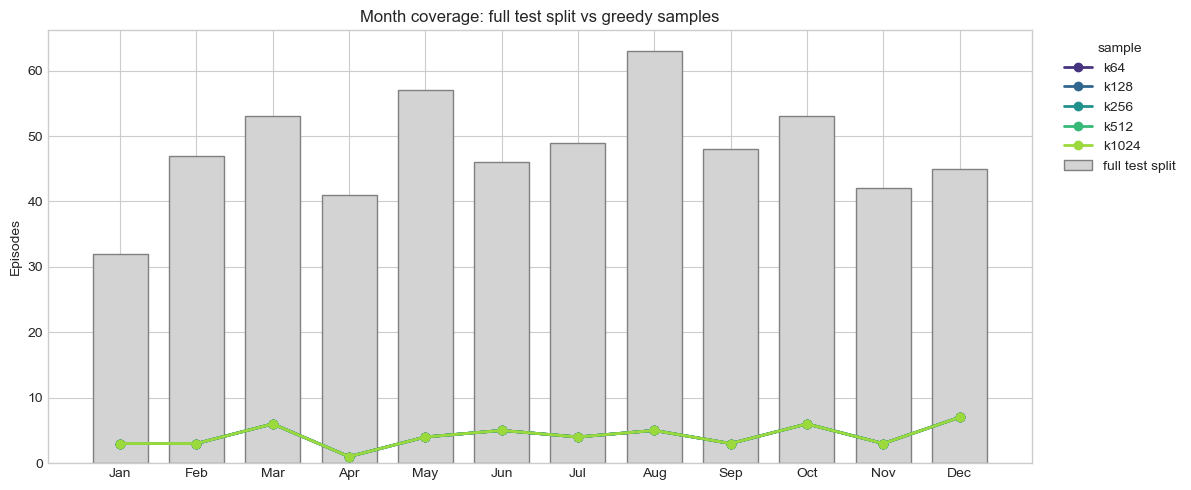

In [16]:
print_plot_sources("test distribution vs greedy sample distributions", [source_files["do_nothing"]["test"]["csv"], *[files["csv"] for files in source_files["greedy"].values()]])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, 13)
full_counts = test_month_counts.set_index("month_num").reindex(x)["test_count"].fillna(0)
ax.bar(x, full_counts, width=0.72, label="full test split", color="lightgray", edgecolor="gray")
for label in LOADED_GREEDY_LABELS:
    sub = coverage[coverage["run_label"] == label].set_index("month_num").reindex(x)
    ax.plot(x, sub["sample_count"].fillna(0), marker="o", linewidth=2, label=label, color=RUN_COLORS[label])
ax.set_xticks(x, MONTH_NAMES)
ax.set_ylabel("Episodes")
ax.set_title("Month coverage: full test split vs greedy samples")
ax.legend(title="sample", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


## 6. Greedy Evaluation Folder Discovery

Use this audit when new 64/128/256/512/1024/1208 greedy folders are downloaded. If a folder appears here but not in the loaded source table above, add its path to `GREEDY_RUNS` or adjust `GREEDY_DISCOVERY_PATTERNS` in the configuration cell.


In [17]:
candidate_greedy_folders = []
for root in [OUTPUTS_DIR, GREEDY_EVAL_DIR]:
    if not root.exists():
        continue
    for pattern in GREEDY_DISCOVERY_PATTERNS:
        candidate_greedy_folders.extend(sorted(root.glob(pattern)))

seen = set()
rows = []
for folder in candidate_greedy_folders:
    if not folder.is_dir():
        continue
    key = str(folder.resolve())
    if key in seen:
        continue
    seen.add(key)
    csv_path = folder / "greedy_vs_do_nothing_episodes.csv"
    summary_path = folder / "greedy_vs_do_nothing_summary.json"
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    action_set_size = extract_action_set_size(folder.name)
    rows.append({
        "label_guess": action_set_label(folder, action_set_size=action_set_size),
        "action_set_size": action_set_size,
        "folder": rel(folder),
        "episodes": len(df),
        "has_paired_do_nothing": "do_nothing_survival" in df and pd.to_numeric(df.get("do_nothing_survival"), errors="coerce").notna().any(),
        "mean_greedy_survival_pct": 100.0 * pd.to_numeric(df["greedy_survival"], errors="coerce").mean(),
        "summary_exists": summary_path.exists(),
    })

candidate_table = pd.DataFrame(rows)
if len(candidate_table):
    candidate_table = candidate_table.sort_values(["action_set_size", "folder"], na_position="last")
display(candidate_table if len(candidate_table) else pd.DataFrame(columns=["label_guess", "action_set_size", "folder", "episodes", "has_paired_do_nothing", "mean_greedy_survival_pct", "summary_exists"]))


,label_guess,action_set_size,folder,episodes,has_paired_do_nothing,mean_greedy_survival_pct,summary_exists
5,k64,64,outputs/teacher_student_greedy_eval/test_fast_...,50,True,55.243860,True
2,k128,128,outputs/teacher_student_greedy_eval/test_fast_...,50,True,60.652195,True
3,k256,256,outputs/teacher_student_greedy_eval/test_fast_...,50,True,68.610022,True
7,k256,256,outputs/teacher_student_greedy_eval/wcci_h1_mk...,50,True,69.431407,True
0,k256,256,outputs/wcci_h1_mk256_test_50chronics_nodn,50,False,69.431407,True
4,k512,512,outputs/teacher_student_greedy_eval/test_fast_...,50,True,71.205160,True
8,k512,512,outputs/teacher_student_greedy_eval/wcci_h1_mk...,50,True,65.459687,True
1,k1024,1024,outputs/teacher_student_greedy_eval/test_fast_...,50,True,78.177127,True
6,k1024,1024,outputs/teacher_student_greedy_eval/wcci_h1_mk...,50,True,74.386753,True


## 7. Paper Date Labels

The paper labels in the screenshot look like `Apr_19.1`, `Apr_19.2`, etc. In this WCCI dataset, the natural mapping is:

`Month_XX.1 -> Scenario_month_{2*XX}`

`Month_XX.2 -> Scenario_month_{2*XX+1}`

The direct mapping `Month_XX.* -> Scenario_month_XX` is not useful because it collapses `.1` and `.2` onto the same chronic.

In [18]:
PAPER_DATE_LABELS = [
    "Apr_19.1", "Apr_19.2",
    "Aug_02.1", "Aug_02.2",
    "Dec_16.1", "Dec_16.2",
    "Feb_20.1", "Feb_20.2",
    "Jan_32.1", "Jan_32.2",
    "Jul_28.1", "Jul_28.2",
    "Jun_14.1", "Jun_14.2",
    "Mar_39.1", "Mar_39.2",
    "May_24.1", "May_24.2",
    "Nov_46.1", "Nov_46.2",
    "Oct_05.1", "Oct_05.2",
    "Sep_21.1", "Sep_21.2",
]

ABBR_TO_MONTH = {
    "Jan": "january", "Feb": "february", "Mar": "march", "Apr": "april",
    "May": "may", "Jun": "june", "Jul": "july", "Aug": "august",
    "Sep": "september", "Oct": "october", "Nov": "november", "Dec": "december",
}

all_do_nothing = do_nothing[do_nothing["dataset_split"] == "all"].set_index("chronic_name")
test_names = set(do_nothing[do_nothing["dataset_split"] == "test"]["chronic_name"])
train_names = set(do_nothing[do_nothing["dataset_split"] == "train"]["chronic_name"])

paper_rows = []
for label in PAPER_DATE_LABELS:
    month_abbr, rest = label.split("_")
    base_index_text, variant_text = rest.split(".")
    base_index = int(base_index_text)
    variant = int(variant_text)
    month = ABBR_TO_MONTH[month_abbr]
    scenario_index = 2 * base_index + (variant - 1)
    chronic_name = f"Scenario_{month}_{scenario_index:03d}"
    split = "test" if chronic_name in test_names else ("train" if chronic_name in train_names else "missing")
    if chronic_name in all_do_nothing.index:
        row = all_do_nothing.loc[chronic_name]
        paper_rows.append({
            "paper_label": label,
            "wcci_chronic": chronic_name,
            "global_index": int(row["chronic_index"]),
            "split_seed0": split,
            "do_nothing_survival_pct": 100.0 * float(row["survival"]),
            "full_survival": bool(row["full_survival"]),
            "fingerprint": row["chronic_fingerprint"],
        })
    else:
        paper_rows.append({
            "paper_label": label,
            "wcci_chronic": chronic_name,
            "global_index": scenario_index,
            "split_seed0": split,
            "do_nothing_survival_pct": np.nan,
            "full_survival": np.nan,
            "fingerprint": "missing",
        })

paper_dates = pd.DataFrame(paper_rows)
display(paper_dates.round({"do_nothing_survival_pct": 2}))
display(paper_dates["split_seed0"].value_counts().rename_axis("split_seed0").reset_index(name="n"))

,paper_label,wcci_chronic,global_index,split_seed0,do_nothing_survival_pct,full_survival,fingerprint
0,Apr_19.1,Scenario_april_038,38,train,8.56,False,20499dfb70a1
1,Apr_19.2,Scenario_april_039,39,train,65.68,False,0c7b71149dee
2,Aug_02.1,Scenario_august_004,244,train,76.66,False,8ae2f01dea75
3,Aug_02.2,Scenario_august_005,245,train,51.46,False,f63aaca15775
4,Dec_16.1,Scenario_december_032,512,train,10.22,False,e7485a84e4e5
5,Dec_16.2,Scenario_december_033,513,test,10.06,False,9232a3f3beb0
6,Feb_20.1,Scenario_february_040,760,train,1.14,False,88fcadd7c614
7,Feb_20.2,Scenario_february_041,761,train,1.29,False,497c25766736
8,Jan_32.1,Scenario_january_064,1024,train,16.00,False,7c73bc788176
9,Jan_32.2,Scenario_january_065,1025,train,7.11,False,5d3c9baa0baf


,split_seed0,n
0,train,20
1,test,4
